In [1]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv(r'C:\Users\k9481\OneDrive\Documents\ml databases\diabetes.csv')

In [6]:
df
# Target — 0=no diabetes, 1=diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.shape

(768, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [22]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [ ]:
# ~65% are class 0, ~35% are class 1. This is imbalance — model can cheat by always predicting 0 and still get 65% accuracy. That's why accuracy alone is not enough here.

In [16]:
# Glucose=0, BMI=0, BloodPressure=0 is biologically impossible
# These are actually missing values disguised as 0

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [17]:
# Replace 0 with NaN first
df[cols_with_zeros] = df[cols_with_zeros].replace(0, pd.NA)


In [24]:
df[cols_with_zeros].value_counts()

Glucose  BloodPressure  SkinThickness  Insulin  BMI 
198      66             32             274      41.3    False
56       56             28             45       24.2    False
68       62             13             15       20.1    False
         70             32             66       25.0    False
         106            23             49       35.5    False
                                                        ...  
78       50             32             88       31.0    False
77       82             41             42       35.8    False
         56             30             56       33.3    False
75       64             24             55       29.7    False
74       70             40             49       35.3    False
Name: count, Length: 392, dtype: bool

In [25]:

print(df.isnull().sum())  # now you'll see the real null counts

# Fill with median (safer than mean for medical data)
for col in cols_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())  # should be all zeros now

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


C:\Users\k9481\AppData\Local\Temp\ipykernel_13400\3694305766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\k9481\AppData\Local\Temp\ipykernel_13400\3694305766.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].median(), inplac

In [26]:
# Step 5 — Split Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [27]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


In [28]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # NEW: stratify!
    # Why stratify=y?
# Without it, your test set might accidentally get mostly class 0. stratify=y ensures same 65/35 ratio is maintained in both train and test sets.
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [31]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # NEW: tells model to care equally about both classes
    # Why class_weight='balanced'?
# Without it, model sees 500 class-0 samples vs 268 class-1 samples and learns to favour class 0. balanced internally penalizes mistakes on the minority class more heavily.
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [32]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, log_loss,
                              roc_auc_score)  # NEW metric

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("Accuracy    :", accuracy_score(y_test, y_pred))
print("Log Loss    :", log_loss(y_test, y_prob))
print("ROC-AUC     :", roc_auc_score(y_test, y_prob[:, 1]))  # NEW
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy    : 0.7337662337662337
Log Loss    : 0.5453276399620101
ROC-AUC     : 0.8125925925925926

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


Confusion Matrix:
 [[75 25]
 [16 38]]


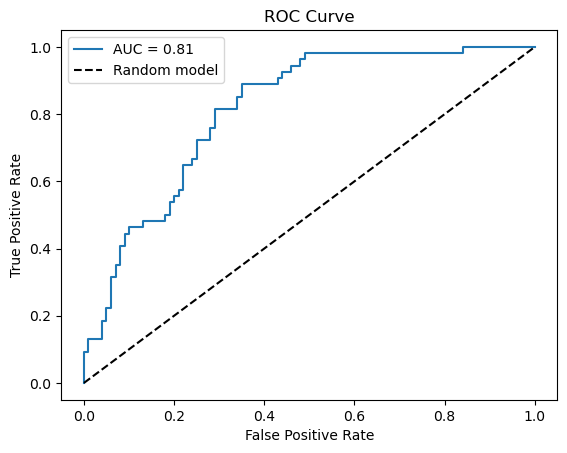

In [33]:
# Step 9 — Understand ROC-AUC (New Concept)
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob[:,1]):.2f}')
plt.plot([0,1], [0,1], 'k--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# AUC       ScoreMeaning
# 0.5       Model is guessing randomly
# 0.7–0.8   Decent model
# 0.8–0.9   Good model
# 0.9+      Excellent model

In [37]:
# Predict for a New Patient
# eg:1
new_patient1 = [[2, 138, 62, 35, 0, 33.6, 0.127, 47]]
#eg:2
# new_patient1 = [[5, 138, 82, 35, 0, 35.6, 0.127, 47]]

new_patient_scaled =scaler.transform(new_patient1)

result = model.predict(new_patient_scaled)
prob   = model.predict_proba(new_patient_scaled)

print("Diabetic?   :", "Yes" if result[0] == 1 else "No")
print("Probability :", round(prob[0][1] * 100, 2), "%")

Diabetic?   : Yes
Probability : 57.73 %


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
# 1. Check your ROC-AUC score
print("ROC-AUC :", roc_auc_score(y_test, y_prob[:, 1]))
# Anything above 0.75 on this dataset is solid.

ROC-AUC : 0.8125925925925926


In [39]:
# Check which feature matters most

import pandas as pd
feature_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age']

importance = pd.Series(model.coef_[0], index=feature_names)
print(importance.abs().sort_values(ascending=False))

Glucose                     1.183444
BMI                         0.709709
Pregnancies                 0.373019
DiabetesPedigreeFunction    0.287745
Age                         0.186393
Insulin                     0.044651
BloodPressure               0.014548
SkinThickness               0.013877
dtype: float64


In [40]:
# put your own realistic values
me = [[0, 85, 70, 18, 60, 18.6, 0.1, 20]]  # edit Age=21 or whatever yours is
me_scaled = scaler.transform(me)
prob = model.predict_proba(me_scaled)
print(f"Your diabetes probability: {prob[0][1]*100:.2f}%")

Your diabetes probability: 1.65%


C:\Users\k9481\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
